# Información inicial

- Universidad de Buenos Aires
- Laboratorio de Sistemas Embebidos
- Especialización en Inteligencia Artificial
- Probabilidad y Estadística para la Inteligencia Artificial
- *Docente:* Camilo Argoty
- *Alumno:* Rodrigo Hernández Código: a2526
- *Fecha:* 18/06/26

# Contexto

Siguiendo con la historia de Don Francisco, con el tiempo y gracias a los análisis de Matías, el pequeño comerciante de barrio cuenta hoy con 5 supermercados: 'Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba'.

También Matías ha avanzado en la Especialización en Inteligencia Artificial. Un día Don Francisco le plantea algunas inquietudes adicionales:

1. Don Francisco quiere entender mejor la afluencia de clientes por mes del supermercado 'Santa Ana'.
2. Más aún, Don Francisco no sabe si puede estar seguro de que la afluencia de clientes son las mismas en todos los supermercados o si hay alguno que se comporte mejor que los demás, y si alguna de las tiendas necesita más atención porque está recibiendo menos clientes que las de las otras.

## Problemas de investigación

De esas inquietudes se desprenden los problemas que abordo en este trabajo:

- **(P1)** Generar datos realistas de afluencia para poder analizarlos → **Punto 1** (simulación con Poisson).
- **(P2)** Caracterizar la afluencia diaria de 'Santa Ana' mes a mes → **Punto 2** (intervalos de confianza).
- **(P3)** Decidir si la afluencia esperada es igual en todas las tiendas → **Punto 3** (ANOVA de un factor).
- **(P4)** Determinar si la tienda con más y la con menos clientes difieren de forma significativa e identificar cuál necesita atención → **Punto 4** (prueba de hipótesis).

> Este notebook **es el informe**: en cada punto desarrollo el planteamiento, el procesamiento de los datos (código), los resultados y el análisis, y al final cierro con las conclusiones generales.


# Punto 1

**(2.5 puntos)** Crear una simulación del número de clientes diarios que van a los almacenes de Don Francisco y de Don Miguel, usando distribuciones Poisson, entre los años 2023, 2024 y 2025. En cada fecha, el parámetro $\lambda_t$ debe ser la suma de los siguientes efectos:

**Efecto anual:**

| Año  | Efecto |
|------|--------|
| 2023 | 1000   |
| 2024 | 1500   |
| 2025 | 2000   |

**Efecto mensual:**

| Mes        | Efecto |
|------------|--------|
| Enero      | 1000   |
| Febrero    | 1500   |
| Marzo      | 2000   |
| Abril      | 2000   |
| Mayo       | 2500   |
| Junio      | 2500   |
| Julio      | 3000   |
| Agosto     | 2500   |
| Septiembre | 2500   |
| Octubre    | 2000   |
| Noviembre  | 1500   |
| Diciembre  | 1000   |

**Efecto diario:**

| Día       | Efecto |
|-----------|--------|
| Domingo   | 1000   |
| Lunes     | 2000   |
| Martes    | 3000   |
| Miércoles | 3500   |
| Jueves    | 3000   |
| Viernes   | 2000   |
| Sábado    | 1000   |

**Efecto por tienda:**

| Tienda      | Efecto |
|-------------|--------|
| Santa Ana   | 5000   |
| La Floresta | 2000   |
| Los Cedros  | 3000   |
| Palermo     | 1000   |
| Córdoba     | 3000   |

## Resolución del Punto 1

**Planteo.** El enunciado da cuatro tablas de efectos (anual, mensual, diario y por tienda) y pide simular los clientes diarios como una Poisson cuyo parámetro $\lambda_t$ es la suma de esos efectos. Simulo las 5 tiendas del enunciado ('Santa Ana', 'La Floresta', 'Los Cedros', 'Palermo' y 'Córdoba') para todas las fechas entre el 01/01/2023 y el 31/12/2025: $1096$ fechas $\times\,5$ tiendas $= 5480$ registros. (El texto arrastra la referencia a "Don Francisco y Don Miguel" del trabajo anterior, pero las tablas y los puntos 2-4 son sobre estas 5 tiendas, así que trabajo sobre ellas.)

**Modelo.** Uso una Poisson porque modela conteos de eventos independientes en un intervalo de tiempo fijo —clientes que entran a un local en un día—, con $\mathbb{E}[X]=\mathrm{Var}(X)=\lambda$. Para cada fecha $t$ y tienda $s$ armo el parámetro de forma aditiva,

$$
\lambda_t(s) = a_{\text{año}(t)} + m_{\text{mes}(t)} + d_{\text{díaSem}(t)} + e_{s},
$$

y muestreo $\text{clientes}_t(s) \sim \mathrm{Poisson}\!\big(\lambda_t(s)\big)$. Con estos efectos $\lambda$ va de $\approx 4000$ (2023, diciembre/enero, fin de semana, Palermo) a $\approx 13500$ (2025, julio, miércoles, Santa Ana). Fijo `np.random.seed(42)` para que la corrida sea reproducible y guardo todo en `df`, que reutilizo en los puntos siguientes.

**Resultado.** El promedio de clientes diarios queda ordenado según el efecto de tienda, porque los efectos de año, mes y día se promedian por igual en las 5 tiendas:

| Tienda | Efecto | Media simulada |
|---|---:|---:|
| Santa Ana | 5000 | $\approx 10717$ |
| Los Cedros | 3000 | $\approx 8714$ |
| Córdoba | 3000 | $\approx 8712$ |
| La Floresta | 2000 | $\approx 7721$ |
| Palermo | 1000 | $\approx 6722$ |


Total de registros: 5,480
Fechas distintas:   1,096  (2023-01-01 a 2025-12-31)

Resumen de clientes/día por tienda:
                mean     std     min      max
tienda                                       
Córdoba       8711.7  1185.2  5906.0  11627.0
La Floresta   7721.1  1188.8  4840.0  10611.0
Los Cedros    8714.2  1186.2  5894.0  11762.0
Palermo       6722.2  1185.6  3840.0   9536.0
Santa Ana    10717.0  1189.4  7799.0  13598.0


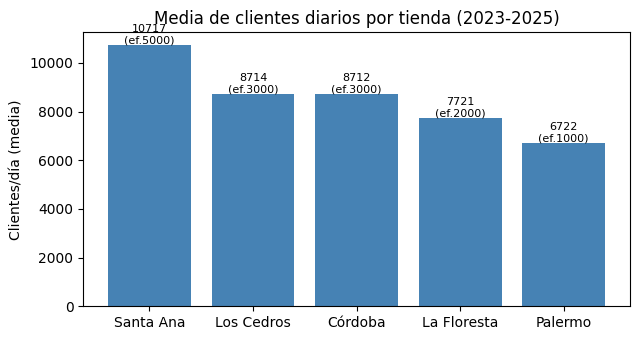

In [37]:
# Punto 1 — simulo clientes diarios ~ Poisson(lambda_t) para las 5 tiendas
# (2023-2025), con lambda_t = efecto_anual + mensual + diario + de tienda.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

np.random.seed(42)

# Tablas de efectos del enunciado
EFECTO_ANUAL = {2023: 1000, 2024: 1500, 2025: 2000}

EFECTO_MENSUAL = {
    1: 1000, 2: 1500, 3: 2000, 4: 2000, 5: 2500, 6: 2500,
    7: 3000, 8: 2500, 9: 2500, 10: 2000, 11: 1500, 12: 1000,
}

# pandas codifica el día de la semana como: 0=Lunes, 1=Martes, ..., 6=Domingo
EFECTO_DIARIO = {
    0: 2000,  # Lunes
    1: 3000,  # Martes
    2: 3500,  # Miércoles
    3: 3000,  # Jueves
    4: 2000,  # Viernes
    5: 1000,  # Sábado
    6: 1000,  # Domingo
}

EFECTO_TIENDA = {
    "Santa Ana": 5000, "La Floresta": 2000, "Los Cedros": 3000,
    "Palermo": 1000, "Córdoba": 3000,
}

# Un registro por (fecha, tienda)
fechas = pd.date_range("2023-01-01", "2025-12-31", freq="D")

registros = []
for fecha in fechas:
    for tienda, efecto_tienda in EFECTO_TIENDA.items():
        lam = (
            EFECTO_ANUAL[fecha.year]
            + EFECTO_MENSUAL[fecha.month]
            + EFECTO_DIARIO[fecha.dayofweek]
            + efecto_tienda
        )
        registros.append({
            "fecha": fecha,
            "anio": fecha.year,
            "mes": fecha.month,
            "tienda": tienda,
            "lambda": lam,
            "clientes": np.random.poisson(lam),
        })

df = pd.DataFrame(registros)

print(f"Total de registros: {len(df):,}")
print(f"Fechas distintas:   {df['fecha'].nunique():,}  ({df['fecha'].min().date()} a {df['fecha'].max().date()})")
print("\nResumen de clientes/día por tienda:")
print(df.groupby("tienda")["clientes"].describe()[["mean", "std", "min", "max"]].round(1))

# Gráfico: media de clientes/día por tienda (ordenada)
medias = df.groupby("tienda")["clientes"].mean().sort_values(ascending=False)
plt.figure(figsize=(6.5, 3.5))
plt.bar(medias.index, medias.values, color="steelblue")
for i, (t, v) in enumerate(medias.items()):
    plt.text(i, v + 60, f"{v:.0f}\n(ef.{EFECTO_TIENDA[t]})", ha="center", fontsize=8)
plt.ylabel("Clientes/día (media)"); plt.title("Media de clientes diarios por tienda (2023-2025)")
plt.tight_layout(); plt.show()

# Punto 2

**(2.5 puntos)** Con base en los datos generados, determinen intervalos de confianza empíricos para el supermercado 'Santa Ana' en cada mes, para significancias del 95 % y el 99 %.

## Resolución del Punto 2

**Planteo.** Para 'Santa Ana' busco, en cada mes, el rango de afluencia diaria que concentra el 95 % y el 99 % de los días. Uno los tres años (2023-2025) y trabajo mes calendario por mes calendario.

**Método.** La materia define la confianza de un intervalo $I$ para una variable $X$ como $P(X\in I)$, con la forma $(\mu - k^{*}\sigma,\ \mu + k^{*}\sigma)$ y valores críticos $k^{*}=1{,}96$ (95 %) y $k^{*}=2{,}575$ (99 %). Como tengo la muestra completa generada en el Punto 1, uso la **versión empírica de ese intervalo**: reemplazo $\mu \pm k^{*}\sigma$ por los **percentiles muestrales**, recortando una cola de $(1-p)/2$ a cada lado,

$$
\text{IC}_p^{\text{emp}} = \Big[\,\widehat{Q}\!\left(\tfrac{1-p}{2}\right),\ \ \widehat{Q}\!\left(\tfrac{1+p}{2}\right)\Big],
$$

es decir, percentiles $2{,}5$/$97{,}5$ para el 95 % y $0{,}5$/$99{,}5$ para el 99 %. No exige suponer normalidad y es robusto a la asimetría. (Es distinto del IC clásico para la *media* como parámetro, mucho más angosto por el factor $1/\sqrt{n}$; acá la inquietud de Don Francisco es caracterizar la afluencia diaria, que es justamente $P(X\in I)$.)

**Resultados** (tabla y bandas en la celda de código). De los intervalos obtenidos observo que:

- el IC al **99 % es más ancho** que el del 95 %, como corresponde a una confianza mayor;
- aparece el **patrón estacional** del efecto mensual: los intervalos suben en invierno (pico en **Julio**, efecto $3000$) y bajan en verano (**Diciembre/Enero**, efecto $1000$);
- al unir los tres años, el IC también recoge la **tendencia anual creciente** ($+1000$ por año), lo que ensancha algo cada intervalo respecto del que daría un solo año.

**Empírico vs. paramétrico.** Comparo el IC empírico con el paramétrico $\mu \pm k^{*}\sigma$ de la materia. Al 95 % casi coinciden (p. ej. **Julio:** empírico $[9910,\,13550]$ vs. paramétrico $[9634,\,13869]$), pero al 99 % el paramétrico se va bastante más ancho en las colas (**Julio:** empírico $[9860,\,13593]$ vs. paramétrico $[8970,\,14534]$). El motivo: dentro de un mes la distribución es una **mezcla** (3 niveles de año $\times$ 7 de día de semana), con colas más cortas que una normal, así que $\mu \pm k\sigma$ **sobreestima** el rango al 99 %. Los percentiles empíricos son más fieles a los datos.


IC empírico (percentiles) vs IC paramétrico (mu ± k*·sigma) — Santa Ana (clientes/día)

Confianza 95%:
       mes  emp95_inf  emp95_sup  par95_inf  par95_sup
     Enero     7981.0    11500.0     7731.0    11765.0
   Febrero     8393.0    11846.0     8236.0    12179.0
     Marzo     8936.0    12489.0     8695.0    12644.0
     Abril     8892.0    12500.0     8630.0    12801.0
      Mayo     9410.0    12894.0     9287.0    13165.0
     Junio     9568.0    12953.0     9238.0    13157.0
     Julio     9910.0    13550.0     9634.0    13869.0
    Agosto     9468.0    13024.0     9249.0    13169.0
Septiembre     9514.0    12983.0     9237.0    13176.0
   Octubre     8966.0    12451.0     8714.0    12789.0
 Noviembre     8445.0    11848.0     8268.0    12115.0
 Diciembre     7928.0    11535.0     7659.0    11741.0

Confianza 99%:
       mes  emp99_inf  emp99_sup  par99_inf  par99_sup
     Enero     7873.0    11680.0     7097.0    12399.0
   Febrero     8314.0    12094.0     7616.0    12799.0
 

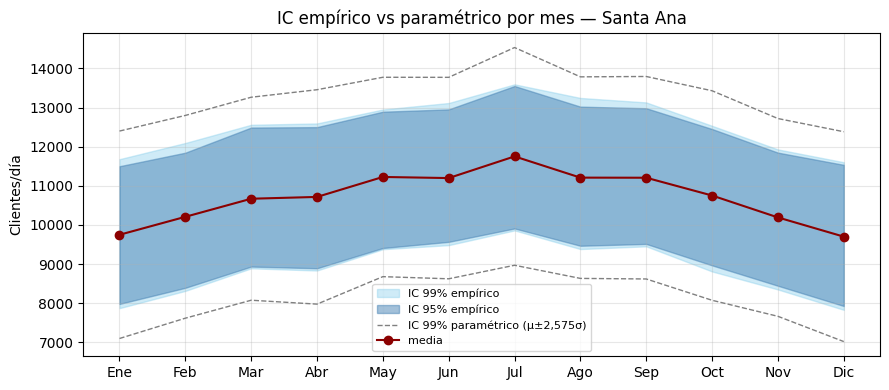

In [38]:
# Punto 2 — IC empírico (percentiles) de la afluencia diaria de 'Santa Ana'
# por mes calendario (2023-2025), comparado con el IC paramétrico (mu ± k*·sigma).

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as st

MESES = {1: "Enero", 2: "Febrero", 3: "Marzo", 4: "Abril", 5: "Mayo", 6: "Junio",
         7: "Julio", 8: "Agosto", 9: "Septiembre", 10: "Octubre", 11: "Noviembre", 12: "Diciembre"}

# valores críticos de la materia
k95 = st.norm.ppf(1 - 0.05/2)   # 1.96
k99 = st.norm.ppf(1 - 0.01/2)   # 2.575

df_sa = df[df["tienda"] == "Santa Ana"]

filas = []
for mes in range(1, 13):
    datos = df_sa.loc[df_sa["mes"] == mes, "clientes"].values
    mu, sigma = datos.mean(), datos.std(ddof=1)
    # IC empírico (percentiles)
    e95i, e95s = np.percentile(datos, [2.5, 97.5])
    e99i, e99s = np.percentile(datos, [0.5, 99.5])
    # IC paramétrico (mu ± k*·sigma)
    p95i, p95s = mu - k95 * sigma, mu + k95 * sigma
    p99i, p99s = mu - k99 * sigma, mu + k99 * sigma
    filas.append({"mes": MESES[mes], "media": mu,
                  "emp95_inf": e95i, "emp95_sup": e95s, "par95_inf": p95i, "par95_sup": p95s,
                  "emp99_inf": e99i, "emp99_sup": e99s, "par99_inf": p99i, "par99_sup": p99s})

tabla = pd.DataFrame(filas)

print("IC empírico (percentiles) vs IC paramétrico (mu ± k*·sigma) — Santa Ana (clientes/día)\n")
print("Confianza 95%:")
print(tabla[["mes", "emp95_inf", "emp95_sup", "par95_inf", "par95_sup"]].round(0).to_string(index=False))
print("\nConfianza 99%:")
print(tabla[["mes", "emp99_inf", "emp99_sup", "par99_inf", "par99_sup"]].round(0).to_string(index=False))

# Gráfico: bandas empíricas (relleno) y banda paramétrica al 99% (línea punteada) por mes
x = np.arange(1, 13)
plt.figure(figsize=(9, 4))
plt.fill_between(x, tabla["emp99_inf"], tabla["emp99_sup"], color="skyblue", alpha=0.4, label="IC 99% empírico")
plt.fill_between(x, tabla["emp95_inf"], tabla["emp95_sup"], color="steelblue", alpha=0.5, label="IC 95% empírico")
plt.plot(x, tabla["par99_inf"], "--", color="gray", lw=1, label="IC 99% paramétrico (μ±2,575σ)")
plt.plot(x, tabla["par99_sup"], "--", color="gray", lw=1)
plt.plot(x, tabla["media"], "o-", color="darkred", label="media")
plt.xticks(x, [MESES[m][:3] for m in range(1, 13)])
plt.ylabel("Clientes/día"); plt.title("IC empírico vs paramétrico por mes — Santa Ana"); plt.legend(fontsize=8)
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()


# Punto 3

**(2.5 puntos)** De igual manera, realicen pruebas ANOVA para determinar si los clientes esperados de todas las tiendas son iguales o no, con significancia del 95 %.

## Resolución del Punto 3

**Planteo.** Tengo una variable numérica (clientes/día) medida en $k=5$ grupos (las tiendas) y quiero ver si la afluencia esperada es igual en todas: es el caso de un **ANOVA de un factor**. Planteo

$$
H_0:\ \mu_{\text{S.Ana}}=\mu_{\text{Floresta}}=\mu_{\text{Cedros}}=\mu_{\text{Palermo}}=\mu_{\text{Córdoba}}
\quad\text{vs.}\quad H_1:\ \text{al menos una media difiere},
$$

con $\alpha = 0{,}05$.

**Requisitos.** Antes de aplicarlo verifico los supuestos:

1. *Independencia:* cada conteo se generó de forma independiente (una muestra Poisson por día y tienda). ✓
2. *Normalidad por grupo:* los datos son Poisson, pero con $\lambda$ grande ($\gtrsim 4000$) una $\mathrm{Poisson}(\lambda)$ es aproximadamente $\mathcal{N}(\lambda,\lambda)$ por el TCL. ✓
3. *Homocedasticidad:* el test de Levene da $p\approx 1$, así que no rechazo la igualdad de varianzas. Es esperable: dentro de cada tienda la dispersión está dominada por la estructura temporal común (año, mes, día), idéntica en las 5, y el ruido Poisson ($\sigma\approx\sqrt{\lambda}\approx 90$) es despreciable frente a esa dispersión ($\sigma\approx 1186$). ✓

**Estadístico.** El ANOVA descompone la variabilidad total, $SS_{\text{total}} = SS_{\text{entre}} + SS_{\text{dentro}}$, y compara los cuadrados medios con una $F$ de Snedecor de $k-1$ y $N-k$ grados de libertad:

$$
F = \frac{SS_{\text{entre}}/(k-1)}{SS_{\text{dentro}}/(N-k)}.
$$

**Resultados.** Con $k=5$ tiendas y $N=5480$ observaciones ($N-k = 5475$):

| Fuente de variación | Suma de cuadrados | g.l. | Cuadrado medio | $F$ |
|---|---:|---:|---:|---:|
| Entre (tiendas) | $\approx 9{,}614\times 10^{9}$ | 4 | $\approx 2{,}403\times 10^{9}$ | **1705,7** |
| Dentro (error) | $\approx 7{,}715\times 10^{9}$ | 5475 | $\approx 1{,}409\times 10^{6}$ | |
| Total | $\approx 1{,}733\times 10^{10}$ | 5479 | | |

**Decisión.** El punto crítico es $F_{4,\,5475;\,0{,}05}\approx 2{,}37$. Como

$$
F_{\text{exp}} = 1705{,}7 \;\gg\; 2{,}37 = F_{\text{teo}}, \qquad p\text{-valor} \approx 0 < 0{,}05 = \alpha,
$$

**rechazo $H_0$**: la afluencia esperada no es igual en todas las tiendas.

**Test a posteriori (Tukey HSD).** Rechazada $H_0$, uso comparaciones múltiples de Tukey (controla el error por familia) para identificar qué tiendas difieren. Obtengo

$$
\text{Palermo} < \text{La Floresta} < \{\text{Córdoba} = \text{Los Cedros}\} < \text{Santa Ana},
$$

con todas las parejas significativas ($p\text{-adj}\approx 0$) **excepto Córdoba vs Los Cedros**, que comparten el mismo efecto de tienda ($3000$) y el test no distingue.


Levene (homocedasticidad): estadístico = 0.0083, p-valor = 0.9999
  -> p alto: NO se rechaza la igualdad de varianzas (se cumple el requisito)

Tabla de ANOVA:
                 Suma de cuadrados  g.l.  Cuadrado medio
Entre (tiendas)    9,613,549,028.8     4 2,403,387,257.2
Dentro (error)     7,714,653,145.6  5475     1,409,069.1
Total             17,328,202,174.5  5479             NaN

F_exp = 1705.6561   |   F_teo = F(4,5475,0.05) = 2.3736   |   p-valor = 0
Como F_exp >> F_teo y p < 0.05  ->  SE RECHAZA H0 (las medias NO son todas iguales)

Comparaciones múltiples (Tukey HSD):
         Multiple Comparison of Means - Tukey HSD, FWER=0.05         
   group1      group2    meandiff  p-adj   lower      upper    reject
---------------------------------------------------------------------
    Córdoba La Floresta   -990.563   0.0 -1128.9289   -852.197   True
    Córdoba  Los Cedros     2.4945   1.0  -135.8714   140.8604  False
    Córdoba     Palermo -1989.4662   0.0 -2127.8322 -1851.1003   

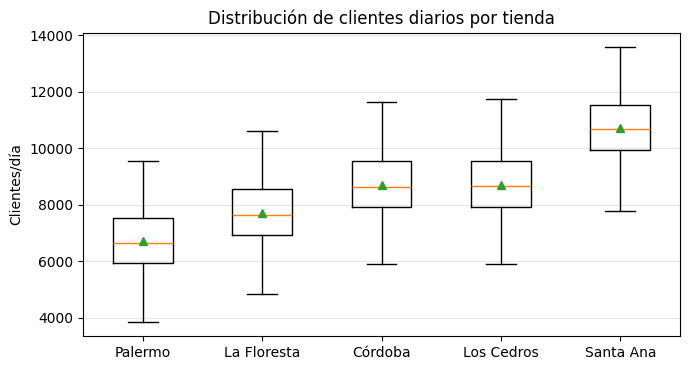

In [39]:
# Punto 3 — ANOVA de un factor (tienda) sobre los clientes diarios + Tukey.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import f as f_dist
from statsmodels.stats.multicomp import pairwise_tukeyhsd

tiendas = list(EFECTO_TIENDA.keys())
grupos = [df.loc[df["tienda"] == t, "clientes"].values for t in tiendas]

# (1) Requisito: homogeneidad de varianzas (Levene)
lev = stats.levene(*grupos)
print(f"Levene (homocedasticidad): estadístico = {lev.statistic:.4f}, p-valor = {lev.pvalue:.4f}")
print("  -> p alto: NO se rechaza la igualdad de varianzas (se cumple el requisito)\n")

# (2) ANOVA con scipy
F, p = stats.f_oneway(*grupos)

# (3) Tabla de ANOVA armada a mano
k = len(grupos)
N = sum(len(g) for g in grupos)
todos = np.concatenate(grupos)
media_global = todos.mean()
SS_entre  = sum(len(g) * (g.mean() - media_global) ** 2 for g in grupos)
SS_dentro = sum(((g - g.mean()) ** 2).sum() for g in grupos)
SS_total  = SS_entre + SS_dentro
gl_entre, gl_dentro = k - 1, N - k
tabla_anova = pd.DataFrame({
    "Suma de cuadrados": [SS_entre, SS_dentro, SS_total],
    "g.l.": [gl_entre, gl_dentro, N - 1],
    "Cuadrado medio": [SS_entre / gl_entre, SS_dentro / gl_dentro, np.nan],
}, index=["Entre (tiendas)", "Dentro (error)", "Total"])
print("Tabla de ANOVA:")
print(tabla_anova.to_string(float_format=lambda v: f"{v:,.1f}"))

F_crit = f_dist.ppf(0.95, gl_entre, gl_dentro)
print(f"\nF_exp = {F:.4f}   |   F_teo = F(4,5475,0.05) = {F_crit:.4f}   |   p-valor = {p:.3g}")
print(f"Como F_exp >> F_teo y p < 0.05  ->  SE RECHAZA H0 (las medias NO son todas iguales)")

# (4) Test a posteriori de Tukey
print("\nComparaciones múltiples (Tukey HSD):")
tukey = pairwise_tukeyhsd(df["clientes"].values, df["tienda"].values, alpha=0.05)
print(tukey.summary())

# Gráfico: boxplot de clientes/día por tienda
orden = df.groupby("tienda")["clientes"].mean().sort_values().index
plt.figure(figsize=(7, 3.8))
plt.boxplot([df.loc[df["tienda"] == t, "clientes"] for t in orden], tick_labels=orden, showmeans=True)
plt.ylabel("Clientes/día"); plt.title("Distribución de clientes diarios por tienda")
plt.grid(alpha=0.3, axis="y"); plt.tight_layout(); plt.show()

# Punto 4

**(2.5 puntos)** Finalmente, identifiquen la tienda con mayor promedio y la tienda con menor promedio de clientes y realicen una prueba de hipótesis para determinar si la diferencia entre ellas es distinta de cero o no. Verifiquen si las tiendas identificadas corresponden a las tiendas con mayores y menores efectos.

## Resolución del Punto 4

**Identificación.** Ordeno las medias del Punto 1: la mayor es **Santa Ana** ($\approx 10717$ clientes/día) y la menor **Palermo** ($\approx 6722$).

**Planteo de la prueba.** Comparo las medias de esas dos tiendas (dos poblaciones, varianzas desconocidas). Hipótesis bilateral:

$$
H_0:\ \mu_{\text{S.Ana}} - \mu_{\text{Palermo}} = 0 \qquad\text{vs.}\qquad H_1:\ \mu_{\text{S.Ana}} - \mu_{\text{Palermo}} \neq 0,
$$

con $\alpha = 0{,}05$. Uso la **prueba $t$ de dos muestras** (variante de Welch, que no asume varianzas iguales):

$$
t = \frac{\bar{x}_1 - \bar{x}_2}{\sqrt{s_1^2/n_1 + s_2^2/n_2}}.
$$

**Decisión.** Obtengo $t \approx 78{,}8$ con $p\text{-valor}\approx 0 < 0{,}05$, así que **rechazo $H_0$**: la diferencia ($\approx 3995$ clientes/día) es significativamente distinta de cero (el IC 95 % de la diferencia no contiene al $0$).

**Verificación contra los efectos.** Las tiendas extremas coinciden con las de efecto extremo: Santa Ana tiene el **mayor** efecto ($5000$) y Palermo el **menor** ($1000$). Más aún, la diferencia de medias observada ($\approx 3995$) es casi igual a la diferencia de efectos ($5000 - 1000 = 4000$): coherente con el modelo aditivo, donde año, mes y día son comunes a todas las tiendas y la diferencia entre dos tiendas queda determinada por sus efectos de tienda.

**Conclusión para Don Francisco.** Palermo es la tienda que recibe significativamente menos clientes y, por lo tanto, la que necesitaría más atención.


In [40]:
# Punto 4 — tienda de mayor y menor promedio + prueba t para su diferencia.

import numpy as np
from scipy import stats

medias = df.groupby("tienda")["clientes"].mean()
tienda_max = medias.idxmax()
tienda_min = medias.idxmin()
print("Promedios de clientes/día por tienda (de mayor a menor):")
print(medias.sort_values(ascending=False).round(1))
print(f"\nMayor promedio: {tienda_max} ({medias[tienda_max]:.1f})")
print(f"Menor promedio: {tienda_min} ({medias[tienda_min]:.1f})")

# Prueba t de Welch (dos muestras, varianzas desconocidas)
a = df.loc[df["tienda"] == tienda_max, "clientes"].values
b = df.loc[df["tienda"] == tienda_min, "clientes"].values
tt = stats.ttest_ind(a, b, equal_var=False)
dif = a.mean() - b.mean()

print(f"\nH0: mu({tienda_max}) - mu({tienda_min}) = 0   vs   H1: != 0")
print(f"Diferencia de medias = {dif:.1f} clientes/día")
print(f"t = {tt.statistic:.3f}   p-valor = {tt.pvalue:.3g}")
print("  -> p < 0.05  =>  SE RECHAZA H0: la diferencia es distinta de cero\n")

# Verificación contra los efectos de tienda
ef_max, ef_min = EFECTO_TIENDA[tienda_max], EFECTO_TIENDA[tienda_min]
ef_mayor = max(EFECTO_TIENDA, key=EFECTO_TIENDA.get)
ef_menor = min(EFECTO_TIENDA, key=EFECTO_TIENDA.get)
print(f"Efecto de {tienda_max} = {ef_max}  (mayor efecto: {ef_mayor})  -> coincide: {tienda_max == ef_mayor}")
print(f"Efecto de {tienda_min} = {ef_min}  (menor efecto: {ef_menor})  -> coincide: {tienda_min == ef_menor}")
print(f"Diferencia de efectos = {ef_max - ef_min}  ~  diferencia de medias observada = {dif:.1f}")

Promedios de clientes/día por tienda (de mayor a menor):
tienda
Santa Ana      10717.0
Los Cedros      8714.2
Córdoba         8711.7
La Floresta     7721.1
Palermo         6722.2
Name: clientes, dtype: float64

Mayor promedio: Santa Ana (10717.0)
Menor promedio: Palermo (6722.2)

H0: mu(Santa Ana) - mu(Palermo) = 0   vs   H1: != 0
Diferencia de medias = 3994.8 clientes/día
t = 78.750   p-valor = 0
  -> p < 0.05  =>  SE RECHAZA H0: la diferencia es distinta de cero

Efecto de Santa Ana = 5000  (mayor efecto: Santa Ana)  -> coincide: True
Efecto de Palermo = 1000  (menor efecto: Palermo)  -> coincide: True
Diferencia de efectos = 4000  ~  diferencia de medias observada = 3994.8


# Conclusiones generales

Cierro retomando las dos inquietudes de Don Francisco:

**1. Afluencia de 'Santa Ana' por mes.** Los intervalos de confianza empíricos (Punto 2) muestran una afluencia diaria con un patrón estacional claro: máxima en invierno (pico en **julio**) y mínima en verano (**diciembre/enero**), sobre una tendencia creciente año a año. El IC al 99 % resulta más ancho que el del 95 %, como corresponde a una mayor confianza.

**2. ¿Se comportan igual las tiendas? ¿Alguna necesita atención?** No se comportan igual. El ANOVA (Punto 3) rechaza la igualdad de medias ($F\approx 1705{,}7$, $p\approx 0$), y el test de Tukey ordena las tiendas como

$$
\text{Palermo} < \text{La Floresta} < \{\text{Córdoba} = \text{Los Cedros}\} < \text{Santa Ana}
$$

(Córdoba y Los Cedros no se distinguen porque comparten el mismo efecto de tienda). La prueba de hipótesis (Punto 4) confirma que la diferencia entre la tienda de **mayor** afluencia (**Santa Ana**) y la de **menor** (**Palermo**) es significativamente distinta de cero ($t\approx 78{,}8$, $p\approx 0$).

**Recomendación.** **Palermo** es la tienda que recibe significativamente menos clientes y, por lo tanto, la que necesitaría más atención. Como validación del método, las tiendas extremas coinciden con las de efecto de tienda extremo y la diferencia de medias observada ($\approx 3995$) reproduce la diferencia de efectos ($5000 - 1000 = 4000$), lo que da consistencia al modelo aditivo usado en la simulación.

---

*El código utilizado en todo el proceso está incluido en las celdas de cada punto.*
